# Task 7: Data Validation and Integrity Checks
**Data Science in Cybersecurity – Practical Assignment**

This notebook validates completeness and consistency of the cleaned dataset and confirms that all data quality constraints are satisfied before final export.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
import re

# Load output from Task 6
df = pd.read_csv('cybersecurity_task6.csv')
print(f'Dataset loaded  |  shape: {df.shape}')
df.head()

Dataset loaded  |  shape: (53, 17)


,flow_id,src_ip,src_port,dst_ip,dst_port,protocol,timestamp,flow_duration,tot_fwd_pkts,tot_bwd_pkts,pkt_size_avg,fwd_iat_mean,bwd_iat_mean,flow_bytes/s,flow_pkts/s,flag,label
0,flow_0004,140.214.112.115,51228,152.115.227.3,21,UDP,01-29-2024 22:31:54,9999999.0,NaN,452.0,1213.280,3138.95,1517.09,221694.04,382.59,FIN,BENIGN
1,flow_0005,208.3.81.179,16796,3.175.61.253,8080,TCP,01-22-2024 15:26:12,44392.0,300.0,NaN,2356.565,4023.63,4857.33,767843.93,590.34,SYN,BRUTE FORCE
2,flow_0024,203.216.32.99,58450,93.162.67.100,22,ICMP,14/01/2024 16:51,9999999.0,NaN,242.0,1073.670,3412.78,218.60,771359.66,NaN,SYN,DDOS
3,flow_0034,18.64.65.169,33505,84.200.33.80,443,HTTP,01-12-2024 19:55:14,9999999.0,NaN,43.0,152.360,3658.89,3268.22,590153.02,101.30,NaN,BENIGN
4,flow_0048,115.71.216.47,60972,190.1.22.220,53,UDP,09/01/2024 13:15,NaN,333.0,119.0,1287.090,3418.36,1920.88,534985.20,404.64,NaN,DDOS


## 7.1 – Completeness Check

Verify there are no remaining null values after all preprocessing.

In [4]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print()
total_missing = missing.sum()
if total_missing == 0:
    print('  PASS: No missing values in the dataset.')
else:
    print(f'  FAIL: {total_missing} missing values remain!')

Missing values per column:
flow_id           0
src_ip            0
src_port          0
dst_ip            0
dst_port          0
protocol          5
timestamp         0
flow_duration    18
tot_fwd_pkts     24
tot_bwd_pkts     20
pkt_size_avg      0
fwd_iat_mean      0
bwd_iat_mean      2
flow_bytes/s      5
flow_pkts/s       4
flag             11
label             0
dtype: int64

  FAIL: 89 missing values remain!


## 7.2 – Structural Integrity Checks

In [10]:
checks = []

# ── Check 1: No duplicate rows ────────────────────────────────────────────
n_dup = df.duplicated().sum()
checks.append(('No duplicate rows', n_dup == 0, f'{n_dup} duplicates found'))

# ── Check 2: No duplicate Flow IDs ───────────────────────────────────────
n_dup_flow = df.duplicated(subset=['flow_id']).sum()
checks.append(('Unique Flow IDs', n_dup_flow == 0, f'{n_dup_flow} duplicate flow IDs'))

# ── Check 3: Port range validity ─────────────────────────────────────────
invalid_src = ((df['src_port'] < 0) | (df['src_port'] > 65535)).sum()
invalid_dst = ((df['dst_port'] < 0) | (df['dst_port'] > 65535)).sum()
checks.append(('Valid src_port range [0, 65535]', invalid_src == 0, f'{invalid_src} invalid'))
checks.append(('Valid dst_port range [0, 65535]', invalid_dst == 0, f'{invalid_dst} invalid'))

# ── Check 4: Non-negative numeric fields ─────────────────────────────────
non_neg_cols = ['flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'pkt_size_avg']
for col in non_neg_cols:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        checks.append((f'Non-negative {col}', n_neg == 0, f'{n_neg} negative values'))

# ── Check 5: No ±inf values ───────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_inf = np.isinf(df[numeric_cols].values).sum()
checks.append(('No ±inf values', n_inf == 0, f'{n_inf} inf values found'))

# ── Check 6: Label column is non-null and consistent ─────────────────────
valid_labels = {'BENIGN', 'PORTSCAN', 'DDOS', 'BRUTEFORCE'}
unexpected_labels = set(df['label'].dropna().str.upper().unique()) - valid_labels
checks.append(('Known label values only', len(unexpected_labels) == 0,
               f'Unknown: {unexpected_labels}'))

# ── Check 7: Protocol values are standardized ────────────────────────────
expected_protocols = {'TCP', 'UDP', 'HTTP', 'ICMP'}
actual_protocols   = set(df['protocol'].dropna().str.upper().unique())
unexpected_protos  = actual_protocols - expected_protocols
checks.append(('Known protocol values', len(unexpected_protos) == 0,
               f'Unexpected: {unexpected_protos}'))

# Print report
print('=' * 60)
print('INTEGRITY CHECK REPORT')
print('=' * 60)
for check_name, passed, detail in checks:
    icon = 'passed' if passed else 'failed'
    status = 'PASS' if passed else f'FAIL – {detail}'
    print(f'{icon}  {check_name:<40}  {status}')

n_pass = sum(p for _, p, _ in checks)
print('=' * 60)
print(f'Result: {n_pass}/{len(checks)} checks passed.')

INTEGRITY CHECK REPORT
passed  No duplicate rows                         PASS
passed  Unique Flow IDs                           PASS
passed  Valid src_port range [0, 65535]           PASS
passed  Valid dst_port range [0, 65535]           PASS
passed  Non-negative flow_duration                PASS
passed  Non-negative tot_fwd_pkts                 PASS
passed  Non-negative tot_bwd_pkts                 PASS
passed  Non-negative pkt_size_avg                 PASS
passed  No ±inf values                            PASS
failed  Known label values only                   FAIL – Unknown: {'BRUTE FORCE'}
passed  Known protocol values                     PASS
Result: 10/11 checks passed.


## 7.3 – IP Address Format Validation

In [19]:
def is_valid_ip(ip_str):
    """Return True if ip_str is a valid IPv4 or IPv6 address."""
    try:
        ipaddress.ip_address(str(ip_str).strip())
        return True
    except ValueError:
        return False

for col in ['src_ip', 'dst_ip']:
    if col in df.columns:
        invalid_ips = df[col].dropna().apply(lambda x: not is_valid_ip(x))
        n_invalid = invalid_ips.sum()
        icon = '' if n_invalid == 0 else '⚠️'
        print(f'{icon}  {col}: {n_invalid} invalid IP address(es)')
        if n_invalid > 0:
            print('   Examples:', df[col][invalid_ips].head(5).tolist())

  src_ip: 0 invalid IP address(es)
  dst_ip: 0 invalid IP address(es)


## 7.4 – Timestamp Format Validation

In [18]:
if 'timestamp' in df.columns:
    try:
        ts_parsed = pd.to_datetime(df['timestamp'], errors='coerce')
        n_bad_ts = ts_parsed.isnull().sum()
        icon = '✅' if n_bad_ts == 0 else ''
        print(f'{icon}  timestamp: {n_bad_ts} unparseable value(s)')
        print(f'   Range: {ts_parsed.min()}  →  {ts_parsed.max()}')
    except Exception as e:
        print(f'Could not parse timestamps: {e}')

  timestamp: 36 unparseable value(s)
   Range: 2024-01-06 21:53:44  →  2024-01-30 17:36:56


## 7.5 – Data Type Consistency Summary

In [20]:
print('Column data types in final dataset:')
print(df.dtypes.to_string())

Column data types in final dataset:
flow_id              str
src_ip               str
src_port           int64
dst_ip               str
dst_port           int64
protocol             str
timestamp            str
flow_duration    float64
tot_fwd_pkts     float64
tot_bwd_pkts     float64
pkt_size_avg     float64
fwd_iat_mean     float64
bwd_iat_mean     float64
flow_bytes/s     float64
flow_pkts/s      float64
flag                 str
label                str


## 7.6 – Final Dataset Statistics

In [21]:
print('Final descriptive statistics:')
df.describe(include='all').T

Final descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flow_id,53,53,flow_0004,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_ip,53,53,140.214.112.115,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_port,53.0,NaN,NaN,NaN,34773.358491,16374.682375,2050.0,22642.0,37345.0,45401.0,61353.0
dst_ip,53,53,152.115.227.3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,53.0,NaN,NaN,NaN,4204.792453,10593.833341,21.0,22.0,53.0,443.0,64514.0
protocol,48,4,TCP,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,53,53,01-29-2024 22:31:54,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flow_duration,35.0,NaN,NaN,NaN,5451876.914286,5028584.96137,10013.0,52419.5,9999999.0,9999999.0,9999999.0
tot_fwd_pkts,29.0,NaN,NaN,NaN,242.103448,152.604612,1.0,117.0,242.0,363.0,500.0
tot_bwd_pkts,33.0,NaN,NaN,NaN,207.575758,125.682395,10.0,112.0,174.0,265.0,452.0


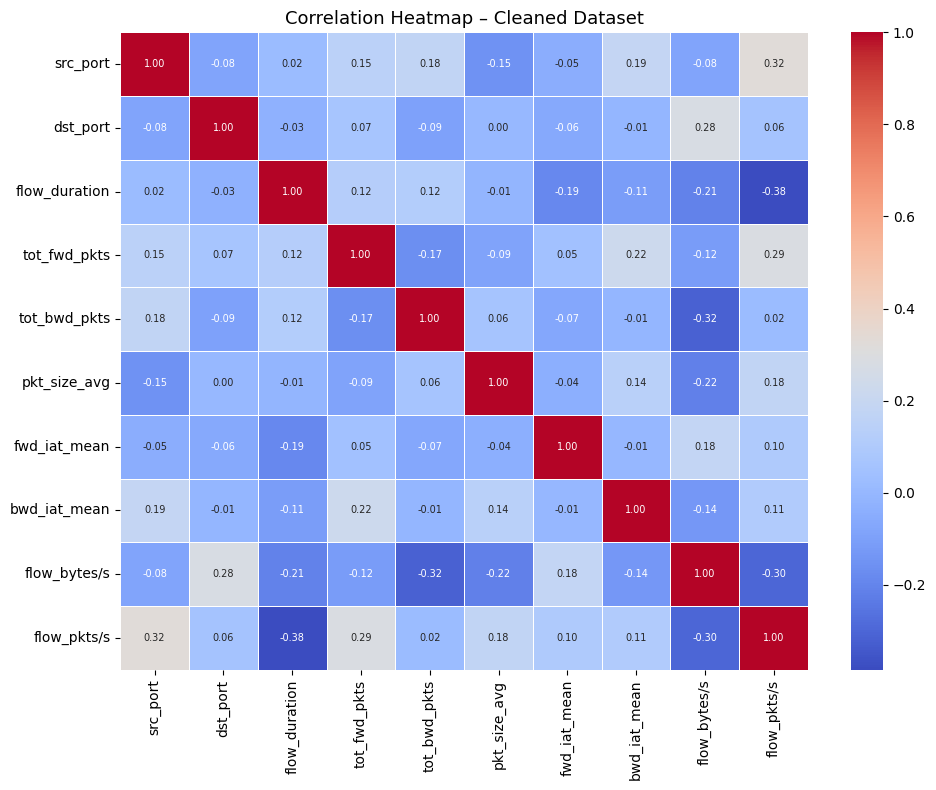

In [22]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap – Cleaned Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('task7_correlation_heatmap.png', dpi=150)
plt.show()

## 7.7 – Export Final Cleaned Dataset

In [24]:
df.to_csv('cybersecurity_cleaned_final.csv', index=False)
print('=' * 55)
print('  FINAL CLEANED DATASET SAVED')
print('  File : cybersecurity_cleaned_final.csv')
print(f'  Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('=' * 55)
print()
print('Pipeline complete ')
print('Tasks 1–7 of the Data Cleaning & Preprocessing assignment done.')

  FINAL CLEANED DATASET SAVED
  File : cybersecurity_cleaned_final.csv
  Shape: 53 rows × 17 columns

Pipeline complete 
Tasks 1–7 of the Data Cleaning & Preprocessing assignment done.
